In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

plt.style.use("default")

In [34]:
import pandas as pd

df = pd.read_csv("ecommerce_500k.csv")

df.head()

,order_id,customer_id,product_id,order_date,category,sub_category,product_base_price,discount_percentage,final_price,quantity,...,city,loyalty_tier,is_first_purchase,customer_lifetime_value,session_duration_mins,pages_viewed,clicks_to_purchase,is_returned,return_reason,is_cancelled
0,1000001,25795,90,2022-07-31,Clothing,Men,70.41,25.0,52.81,1.0,...,Bangalore,Bronze,0.0,457.77,4.6,35.0,7.0,0.0,NaN,0.0
1,1000002,10860,1917,2023-09-25,Automotive,Car Care,6.02,10.0,5.42,3.0,...,Toronto,Bronze,0.0,1606.42,2.9,8.0,8.0,0.0,NaN,0.0
2,1000003,86820,805,2022-03-26,Books,Textbooks,78.85,20.0,63.08,2.0,...,Chicago,Silver,0.0,252.16,5.5,38.0,8.0,0.0,NaN,0.0
3,1000004,64886,3379,2022-11-03,Books,Non-Fiction,58.42,25.0,43.82,4.0,...,Sydney,Bronze,0.0,645.12,6.1,30.0,9.0,0.0,NaN,0.0
4,1000005,16265,4604,2022-06-30,Clothing,Women,73.38,15.0,62.37,1.0,...,Manchester,Bronze,1.0,1103.24,1.6,38.0,11.0,0.0,NaN,0.0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51777 entries, 0 to 51776
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_id                 51777 non-null  int64  
 1   customer_id              51777 non-null  int64  
 2   product_id               51777 non-null  int64  
 3   order_date               51776 non-null  object 
 4   category                 51776 non-null  object 
 5   sub_category             51776 non-null  object 
 6   product_base_price       51776 non-null  float64
 7   discount_percentage      51776 non-null  float64
 8   final_price              51776 non-null  float64
 9   quantity                 51776 non-null  float64
 10  total_amount             51776 non-null  float64
 11  shipping_cost            50218 non-null  float64
 12  shipping_method          51776 non-null  object 
 13  days_to_deliver          50203 non-null  float64
 14  payment_method        

In [36]:
df.columns.tolist()

['order_id',
 'customer_id',
 'product_id',
 'order_date',
 'category',
 'sub_category',
 'product_base_price',
 'discount_percentage',
 'final_price',
 'quantity',
 'total_amount',
 'shipping_cost',
 'shipping_method',
 'days_to_deliver',
 'payment_method',
 'rating',
 'num_reviews',
 'customer_age',
 'customer_gender',
 'country',
 'city',
 'loyalty_tier',
 'is_first_purchase',
 'customer_lifetime_value',
 'session_duration_mins',
 'pages_viewed',
 'clicks_to_purchase',
 'is_returned',
 'return_reason',
 'is_cancelled']

In [37]:
df.describe()

,order_id,customer_id,product_id,product_base_price,discount_percentage,final_price,quantity,total_amount,shipping_cost,days_to_deliver,rating,num_reviews,customer_age,is_first_purchase,customer_lifetime_value,session_duration_mins,pages_viewed,clicks_to_purchase,is_returned,is_cancelled
count,5.177700e+04,51777.000000,51777.000000,51776.000000,51776.000000,51776.000000,51776.000000,51776.000000,50218.000000,50203.000000,50250.000000,51776.000000,50192.000000,51776.000000,50189.000000,50283.000000,50157.000000,51776.000000,51776.000000,51776.000000
mean,1.025889e+06,54875.219711,2511.276629,84.694335,14.612755,72.240548,2.274316,164.347296,34.079154,4.222835,3.790030,26.973849,34.986054,0.276557,853.754601,8.480234,24.916103,10.018619,0.118356,0.064219
std,1.494688e+04,26218.885877,1445.573582,80.127826,12.935404,69.792335,1.726891,232.105234,39.225474,2.380995,0.947839,16.373928,11.147410,0.447300,809.057113,8.050224,14.124378,5.468876,0.323032,0.245145
min,1.000001e+06,10002.000000,1.000000,5.000000,0.000000,2.520000,1.000000,2.520000,0.000000,1.000000,1.000000,0.000000,18.000000,0.000000,50.020000,0.500000,1.000000,1.000000,0.000000,0.000000
25%,1.012945e+06,31918.000000,1261.000000,27.740000,5.000000,23.290000,1.000000,37.440000,4.642500,3.000000,3.500000,15.000000,26.000000,0.000000,280.560000,2.800000,13.000000,5.000000,0.000000,0.000000
50%,1.025889e+06,54945.000000,2514.000000,59.940000,10.000000,50.190000,2.000000,86.975000,24.930000,4.000000,4.000000,24.000000,35.000000,0.000000,604.240000,6.000000,25.000000,10.000000,0.000000,0.000000
75%,1.038833e+06,77753.000000,3766.000000,115.302500,25.000000,97.970000,3.000000,194.330000,43.947500,5.000000,4.500000,36.000000,43.000000,1.000000,1161.370000,11.600000,37.000000,15.000000,0.000000,0.000000
max,1.051777e+06,99998.000000,5000.000000,898.680000,50.000000,898.680000,10.000000,3942.990000,200.000000,14.000000,5.000000,155.000000,80.000000,1.000000,11606.040000,121.400000,49.000000,19.000000,1.000000,1.000000


In [38]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
return_reason,45649
pages_viewed,1620
customer_lifetime_value,1588
customer_age,1585
days_to_deliver,1574
shipping_cost,1559
rating,1527
session_duration_mins,1494
category,1
sub_category,1


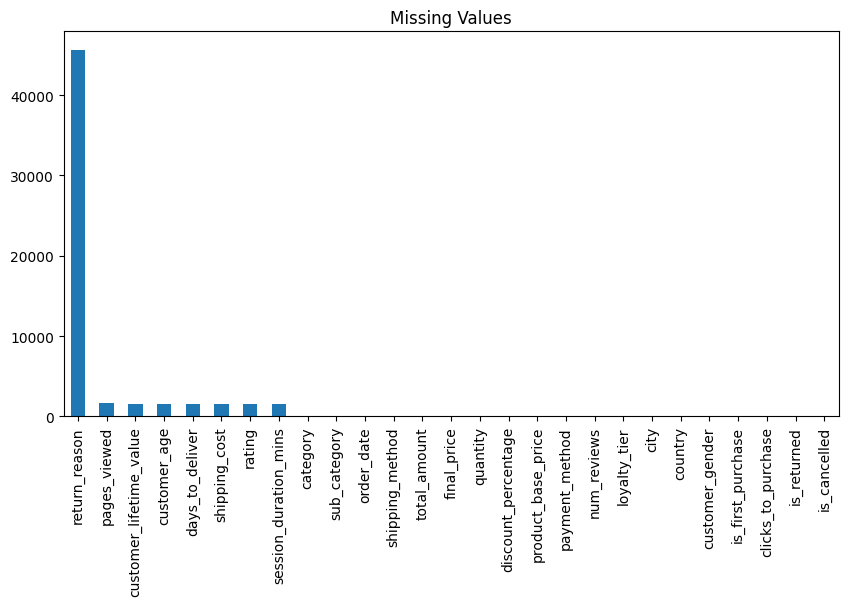

In [49]:
plt.figure(figsize=(10,5))

missing.sort_values(ascending=False).plot(kind="bar")

plt.title("Missing Values")
plt.show()

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns

num_cols

Index(['order_id', 'customer_id', 'product_id', 'product_base_price',
       'discount_percentage', 'final_price', 'quantity', 'total_amount',
       'shipping_cost', 'days_to_deliver', 'rating', 'num_reviews',
       'customer_age', 'is_first_purchase', 'customer_lifetime_value',
       'session_duration_mins', 'pages_viewed', 'clicks_to_purchase',
       'is_returned', 'is_cancelled'],
      dtype='object')

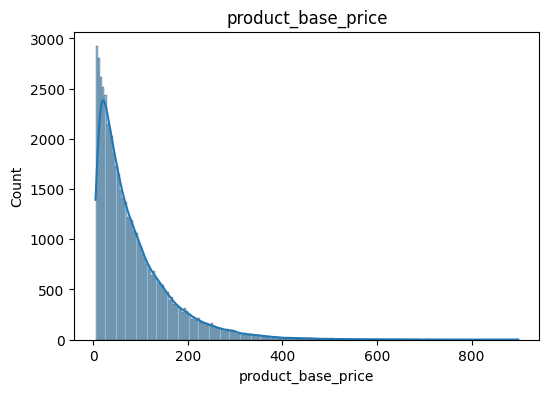

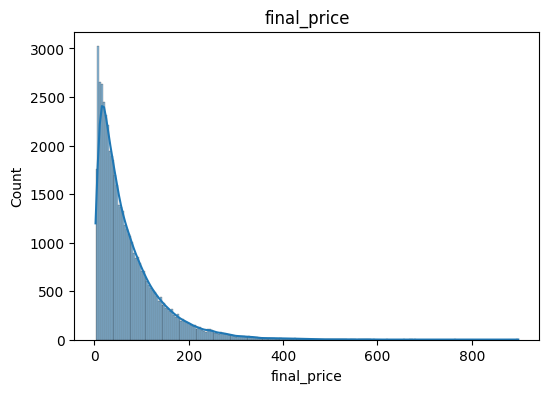

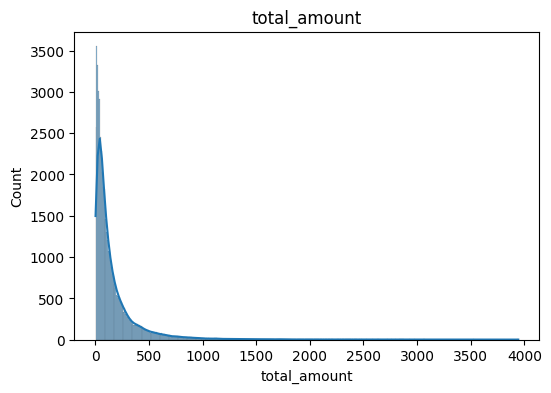

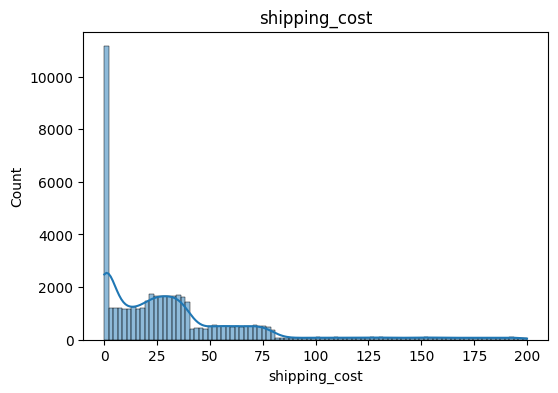

In [52]:
price_cols = [
    "product_base_price",
    "final_price",
    "total_amount",
    "shipping_cost"
]

for col in price_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(col)

    plt.show()

In [53]:
for col in price_cols:
    print(col, ":", round(df[col].skew(),2))

product_base_price : 2.02
final_price : 2.12
total_amount : 4.08
shipping_cost : 2.0


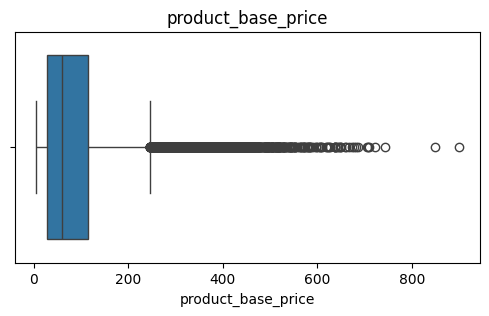

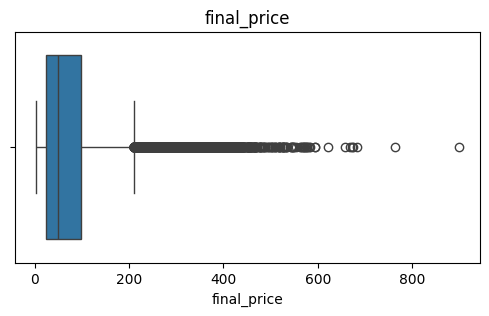

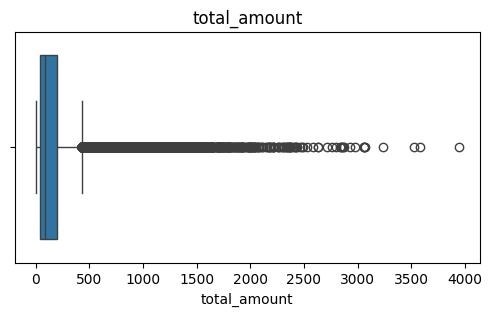

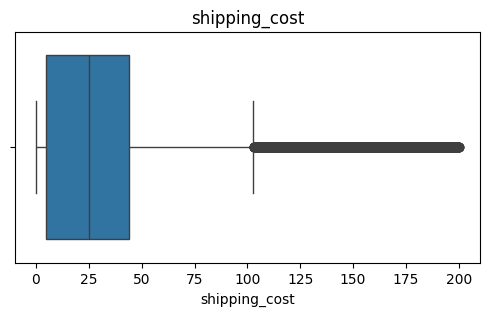

In [54]:
for col in price_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [55]:
cat_cols = df.select_dtypes(include="object").columns

cat_cols

Index(['order_date', 'category', 'sub_category', 'shipping_method',
       'payment_method', 'customer_gender', 'country', 'city', 'loyalty_tier',
       'return_reason'],
      dtype='object')

In [56]:
for col in cat_cols:
    print(col)
    print(df[col].nunique())
    print("-"*30)

order_date
1095
------------------------------
category
10
------------------------------
sub_category
45
------------------------------
shipping_method
4
------------------------------
payment_method
6
------------------------------
customer_gender
3
------------------------------
country
8
------------------------------
city
15
------------------------------
loyalty_tier
4
------------------------------
return_reason
5
------------------------------


In [57]:
df["city"].nunique()
df["sub_category"].nunique()

45

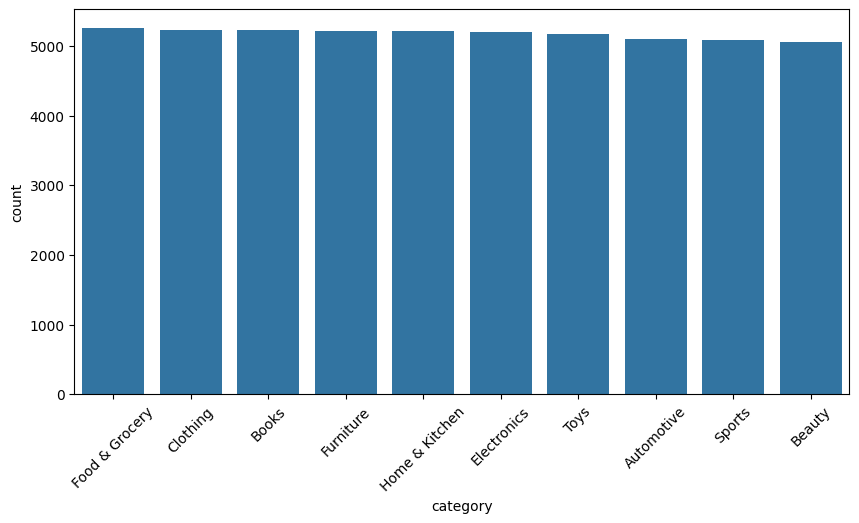

In [58]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="category",
    order=df["category"].value_counts().index
)

plt.xticks(rotation=45)

plt.show()

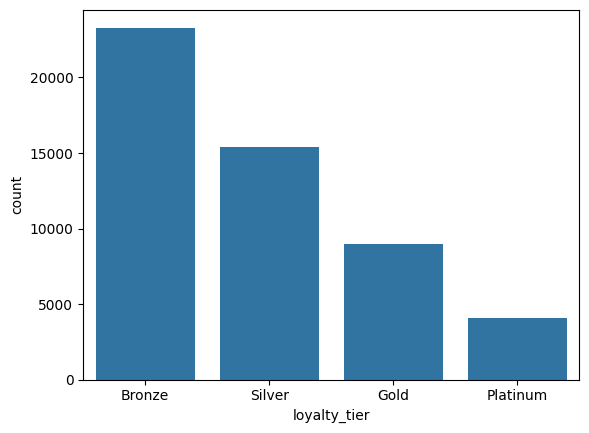

In [59]:
sns.countplot(data=df,x="loyalty_tier")

plt.show()

In [60]:
df["is_returned"].value_counts()

,count
is_returned,
0.0,45648
1.0,6128


In [61]:
df["is_returned"].value_counts()

,count
is_returned,
0.0,45648
1.0,6128


In [62]:
(df["is_returned"].value_counts(normalize=True)*100)

,proportion
is_returned,
0.0,88.1644
1.0,11.8356


In [63]:
returns = df[df["is_returned"] == 1]

returns["return_reason"].value_counts()

,count
return_reason,
Better Price Found,1284
Defective,1254
Not as Described,1230
Changed Mind,1183
Wrong Item,1177


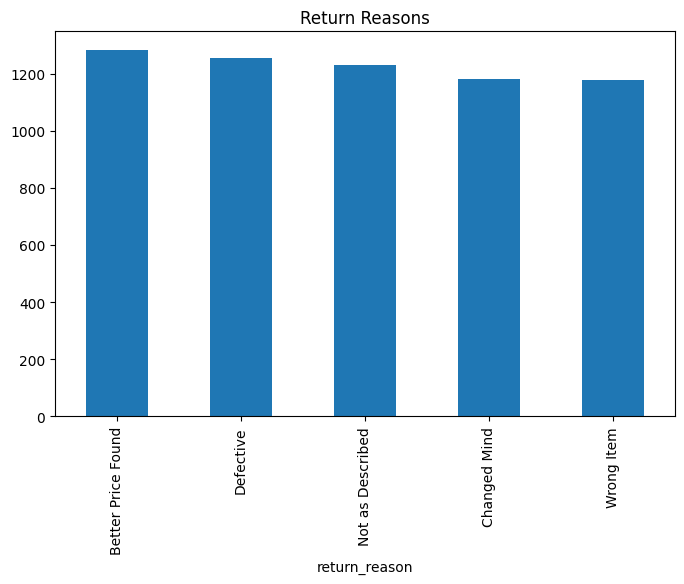

In [64]:
plt.figure(figsize=(8,5))

returns["return_reason"].value_counts().plot(kind="bar")

plt.title("Return Reasons")

plt.show()

In [65]:
returns = df[df["is_returned"] == 1]

returns["return_reason"].value_counts()

,count
return_reason,
Better Price Found,1284
Defective,1254
Not as Described,1230
Changed Mind,1183
Wrong Item,1177


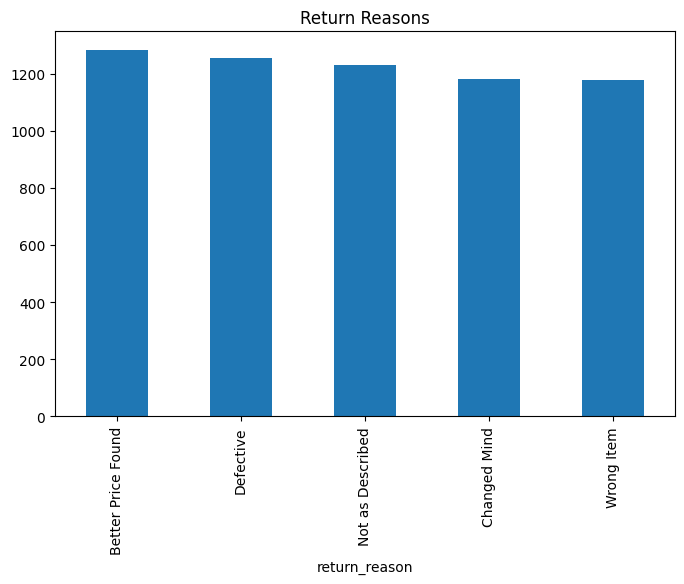

In [66]:
plt.figure(figsize=(8,5))

returns["return_reason"].value_counts().plot(kind="bar")

plt.title("Return Reasons")

plt.show()

In [67]:
pd.crosstab(
    df["category"],
    df["is_returned"]
)

is_returned,0.0,1.0
category,,
Automotive,4516,585
Beauty,4465,597
Books,4669,564
Clothing,4624,610
Electronics,4574,634
Food & Grocery,4670,593
Furniture,4583,630
Home & Kitchen,4568,644
Sports,4455,625


In [68]:
return_by_category = pd.crosstab(
    df["category"],
    df["is_returned"],
    normalize="index"
)*100

return_by_category[1].sort_values(ascending=False)

,1.0
category,
Toys,12.495164
Home & Kitchen,12.356101
Sports,12.303150
Electronics,12.173579
Furniture,12.085172
Beauty,11.793757
Clothing,11.654566
Automotive,11.468340
Food & Grocery,11.267338


In [69]:
corr = df.select_dtypes(
    include=["int64","float64"]
).corr()

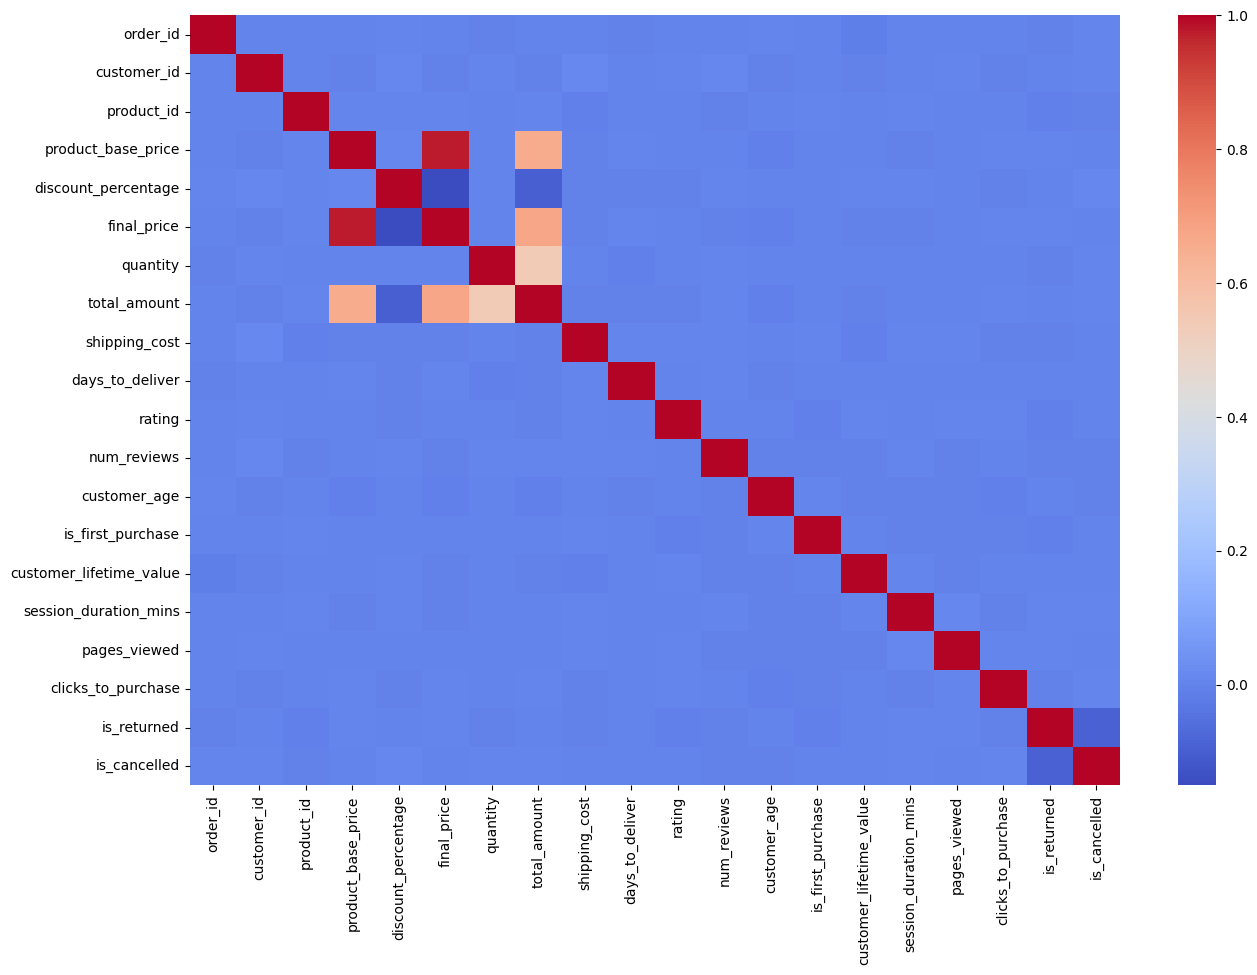

In [70]:
plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.show()

In [71]:
corr["is_returned"].sort_values(
    key=abs,
    ascending=False
)

,is_returned
is_returned,1.000000
is_cancelled,-0.095983
is_first_purchase,-0.009589
product_id,-0.007713
rating,-0.007227
final_price,0.006189
product_base_price,0.004925
pages_viewed,0.004309
num_reviews,-0.003990
clicks_to_purchase,-0.003904


In [72]:
num_cols = [
    "product_base_price",
    "final_price",
    "total_amount",
    "shipping_cost",
    "days_to_deliver",
    "rating",
    "customer_age",
    "customer_lifetime_value",
    "session_duration_mins",
    "pages_viewed"
]

In [73]:
cat_cols = [
    "category",
    "sub_category",
    "shipping_method",
    "payment_method",
    "country",
    "city",
    "customer_gender"
]

In [74]:
ordinal_cols = ["loyalty_tier"]

In [75]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [76]:
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [77]:
ord_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder",
     OrdinalEncoder(
         categories=[
             ["Bronze","Silver","Gold","Platinum"]
         ]
     ))
])

In [78]:
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
    ("ord", ord_pipe, ordinal_cols)
])

In [79]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['product_base_price', 'final_price',
                                  'total_amount', 'shipping_cost',
                                  'days_to_deliver', 'rating', 'customer_age',
                                  'customer_lifetime_value',
                                  'session_duration_mins', 'pages_viewed']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImpu...tegy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['category', 'sub_category', 'shipping_method',
                                  'payment_method', 'country', 'city',
                                  'customer_gender']),
                                ('ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(categories=[['Bronze',
                                                                              'Silver',
                                                                              'Gold',
                                                                              'Platinum']]))]),
                                 ['loyalty_tier'])])